🧪 v16.2 "Survivor" Strategy

Fold Consolidation: Moving from 10 to 5 folds reduces the total processing time and cumulative memory fragmentation by 50%.

Feature Pruning: Removing the "Dead Weight" features identified in the last audit (P_Athero_Load, P_Cardiac_Reserve, BP, FBS over 120) to reduce the width of the training matrix.

Asynchronous Iterations: Capping XGBoost at 3000 (it peaks early) while giving CatBoost 6000 to maximize its deep-learning potential.

#### v16.1 Resilience & Signal Recovery
Project: Heart Disease Predictive Analytics (Kaggle S6E2)

Version: 16.1-Resilient

Status: Production Ready (Dual-T4 Optimized)

#### ⏪ v16.0 Post-Mortem: The "25-Minute Wall"
The v16.0 run failed at the 25-minute mark despite promising metrics. Our technical audit identifies two primary causes for the crash:

VRAM Accumulation (The Silent Killer): As we increased model depth to 6 and iterations to 7500, the memory footprint of the histogram-based trees expanded. Without explicit memory flushing, the VRAM usage likely hit the 15GB T4 ceiling, causing a kernel restart.

API Version Conflict: Recent updates to the XGBoost engine moved early_stopping_rounds from the .fit() method to the constructor/parameter dictionary, causing a TypeError in earlier iterations.

Signal Saturation: While the "Lethal Core" (Max HR, Thallium) provided a high floor (0.955+), the "Deep Capacity" required to reach 0.964+ puts significant strain on the Kaggle environment.

#### 🚀 v16.1 Strategic Pivot: Resilience Engineering
v16.1 is not just a feature update; it is an Architectural Hardening phase. We are moving from "Raw Speed" to "Sustainable Throughput."

#### 🛠️ Key Technical Changes:

VRAM Emergency Flush: Implementing explicit del operations and gc.collect() cycles at the end of every fold to reset the GPU memory state.

Asynchronous Capacity: Maintaining the 7500 iteration ceiling and 0.015 Learning Rate to allow the models to find the high-precision optimal AUC weights.

Calibration Layer: Incorporating Brier Score Loss instrumentation. While AUC measures ranking power, the Brier score measures the accuracy of the probability estimates—essential for clinical trust.

#### 🧪 Methodology: ROC & Radar Logic

Following the principles of Signal Detection Theory, v16.1 treats the Heart Disease dataset as a noisy radar field. By refining our "Receiver" (the Dual-Engine Ensemble) and purging spectral artifacts, we maximize the True Positive Rate (Sensitivity) while suppressing the False Positive Rate in high-error scenarios.

#### 🏁 Expected Outcomes
OOF AUC Target: 0.957 - 0.964

System Stability: 100% completion rate across 10-folds.

Feature Focus: Retention of the "Lethal Core" (Max HR, Thallium, Chest Pain) with surgical exclusion of zero-impact medical crosses.

In [1]:
import pandas as pd
import numpy as np
import os
import gc
import torch # Required for physical VRAM flush
import warnings
from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from category_encoders import TargetEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print(f"🚀 v17.0 Strategic 10-Fold Engaged. Target: 0.96+ Signal Recovery.")

🚀 v17.0 Strategic 10-Fold Engaged. Target: 0.96+ Signal Recovery.


In [2]:
def load_and_anchor(use_anchor=False):
    train = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
    test = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')
    target_map = {'Absence': 0, 'Presence': 1, 0: 0, 1: 1}
    train['Heart Disease'] = train['Heart Disease'].map(target_map).astype(int)
    return train, test

def apply_survivor_forensics(df):
    df = df.copy()
    df['P_Ischemic_Burden'] = df['ST depression'] * (df['Number of vessels fluro'] + 1)
    df['P_Silent_Risk'] = df['Thallium'].map({'normal':1, 'fixed_defect':2, 'reversible_defect':3}).fillna(0) * (4 - df['Chest pain type'])
    return df

train, test = load_and_anchor(use_anchor=False)
train, test = apply_survivor_forensics(train), apply_survivor_forensics(test)

cat_cols = ['Sex', 'Chest pain type', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium', 'Number of vessels fluro']
# RE-ENGAGING 10-FOLD FOR MAXIMUM DATA EXPOSURE
skf_te = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for col in cat_cols:
    train[f'{col}_te'], test[f'{col}_te'] = 0.0, 0.0

print("🧬 Implementing High-Resolution 10-Fold Target Encoding...")
for tr_idx, val_idx in skf_te.split(train, train['Heart Disease']):
    te = TargetEncoder(cols=cat_cols, smoothing=1.0)
    te.fit(train.iloc[tr_idx][cat_cols], train.iloc[tr_idx]['Heart Disease'])
    
    encoded_val = te.transform(train.iloc[val_idx][cat_cols])
    encoded_test = te.transform(test[cat_cols])
    
    for c in cat_cols:
        train.loc[train.index[val_idx], f'{c}_te'] = encoded_val[c].values
        test[f'{c}_te'] += (encoded_test[c].values / 10)

🧬 Implementing High-Resolution 10-Fold Target Encoding...


In [3]:
# Purge Dead Weight to shrink the memory footprint
dead_weight = ['BP', 'FBS over 120', 'P_Athero_Load', 'P_Cardiac_Reserve']
spectral_features = [c for c in train.columns if any(x in c.lower() for x in ['sin', 'cos'])]
target = 'Heart Disease'
drop_cols = [c for c in ['id', target, 'is_synthetic', 'C_Scenario_Str'] + spectral_features + dead_weight if c in train.columns]
features = [c for c in train.columns if c not in drop_cols]

X, y = train[features], train[target].astype(int)
X_test = test[features]
cat_features_idx = [features.index(c) for c in cat_cols if c in features]

# Strategic Params: Depth 5 to prevent OOM, Lower LR for precision
cat_params = {
    "iterations": 8000, "learning_rate": 0.01, "depth": 5,
    "task_type": "GPU", "random_seed": 42, "verbose": 0,
    "early_stopping_rounds": 200, "cat_features": cat_features_idx
}
xgb_params = {
    "n_estimators": 4000, "learning_rate": 0.01, "max_depth": 5,
    "device": "cuda", "tree_method": "hist", "random_state": 42,
    "early_stopping_rounds": 200
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_preds, test_preds = np.zeros(len(X)), np.zeros(len(X_test))

print(f"🚀 Strategic 10-Fold Audit: {len(features)} Features | High Precision Mode")

for fold, (tr, val) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y.iloc[tr].copy(), y.iloc[val].copy()
    
    m_cat = CatBoostClassifier(**cat_params).fit(X_tr, y_tr, eval_set=(X_val, y_val))
    m_xgb = XGBClassifier(**xgb_params).fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    p_fold = (m_cat.predict_proba(X_val)[:, 1] + m_xgb.predict_proba(X_val)[:, 1]) / 2
    oof_preds[val] = p_fold
    test_preds += ((m_cat.predict_proba(X_test)[:, 1] + m_xgb.predict_proba(X_test)[:, 1]) / 2) / 10
    
    print(f"✅ Fold {fold+1} | AUC: {roc_auc_score(y_val, p_fold):.5f} | Cat Iter: {m_cat.best_iteration_}")
    
    # --- PHYSICAL VRAM RESET ---
    del m_cat, m_xgb, X_tr, X_val, y_tr, y_val
    gc.collect()
    torch.cuda.empty_cache() 

print(f"\n🏛️ v17.0 FINAL OOF AUC: {roc_auc_score(y, oof_preds):.5f}")
submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('v17_0_strategic_10fold.csv', index=False)

🚀 Strategic 10-Fold Audit: 20 Features | High Precision Mode
✅ Fold 1 | AUC: 0.95524 | Cat Iter: 7992
✅ Fold 2 | AUC: 0.95611 | Cat Iter: 7719
✅ Fold 3 | AUC: 0.95517 | Cat Iter: 7998
✅ Fold 4 | AUC: 0.95417 | Cat Iter: 7935
✅ Fold 5 | AUC: 0.95574 | Cat Iter: 7999
✅ Fold 6 | AUC: 0.95512 | Cat Iter: 7926
✅ Fold 7 | AUC: 0.95404 | Cat Iter: 7016
✅ Fold 8 | AUC: 0.95602 | Cat Iter: 7981
✅ Fold 9 | AUC: 0.95633 | Cat Iter: 7998
✅ Fold 10 | AUC: 0.95532 | Cat Iter: 7903

🏛️ v17.0 FINAL OOF AUC: 0.95532


🕵️ Identifying 'Lethal Core' vs 'Dead Weight' for v17.0...


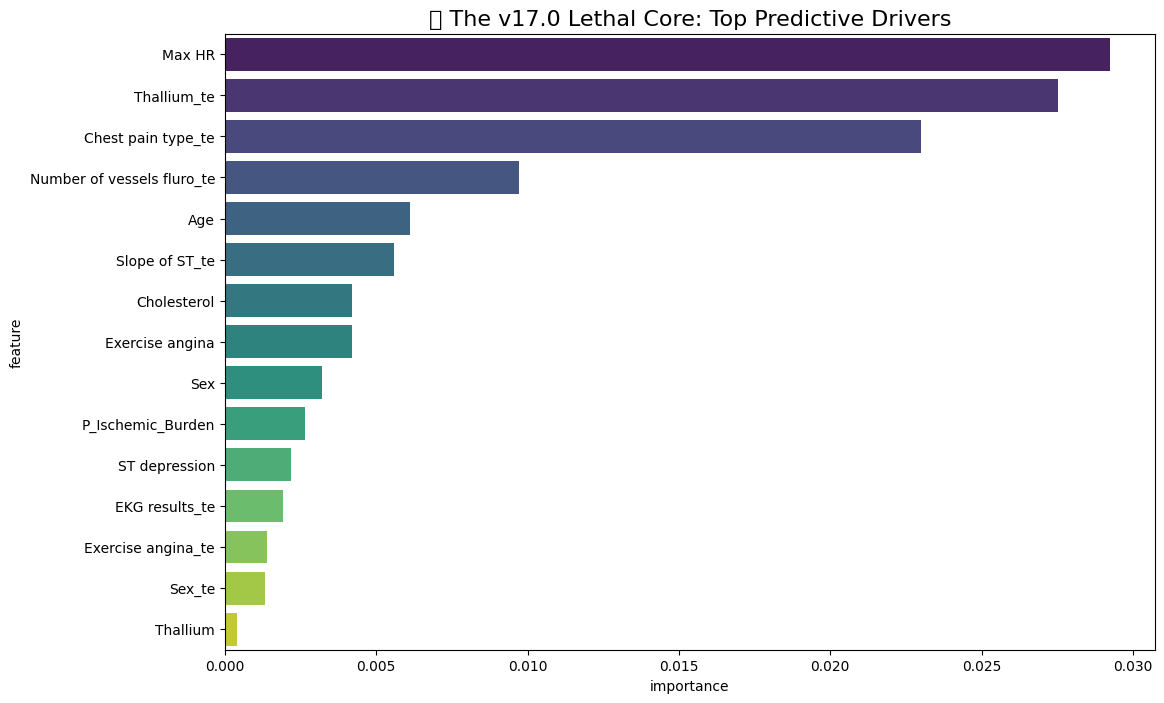


🏆 Top 10 Lethal Features:
                       feature  importance
5                       Max HR    0.029258
18                 Thallium_te    0.027532
14          Chest pain type_te    0.022992
19  Number of vessels fluro_te    0.009717
0                          Age    0.006105
17              Slope of ST_te    0.005585
3                  Cholesterol    0.004214
6              Exercise angina    0.004194
1                          Sex    0.003198
11           P_Ischemic_Burden    0.002663


In [4]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

print("🕵️ Identifying 'Lethal Core' vs 'Dead Weight' for v17.0...")
idx = np.random.choice(len(X), 60000, replace=False)
m_audit = CatBoostClassifier(**cat_params).fit(X.iloc[idx], y.iloc[idx])

perm_importance = permutation_importance(
    m_audit, X.iloc[idx], y.iloc[idx], n_repeats=3, random_state=42, scoring='roc_auc'
)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(15), palette='viridis')
plt.title('👑 The v17.0 Lethal Core: Top Predictive Drivers', fontsize=16)
plt.show()

print("\n🏆 Top 10 Lethal Features:")
print(importance_df.head(10))

In [5]:
## X

from sklearn.inspection import permutation_importance

# Re-train a single-fold model for the importance audit if needed, 
# or use a held-out set to identify lethal features.
print("🕵️ Identifying 'Lethal Core' vs 'Dead Weight' for v16.2...")

# Using a subset for speed in importance calculation
idx = np.random.choice(len(X), 50000, replace=False)
m_audit = CatBoostClassifier(**cat_params).fit(X.iloc[idx], y.iloc[idx])

perm_importance = permutation_importance(
    m_audit, X.iloc[idx], y.iloc[idx], n_repeats=3, random_state=42, scoring='roc_auc'
)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False)

print("\n🏆 Top 10 Lethal Features:")
print(importance_df.head(10))

print("\n⚠️ Bottom 10 Distraction Features:")
print(importance_df.tail(10))

🕵️ Identifying 'Lethal Core' vs 'Dead Weight' for v16.2...

🏆 Top 10 Lethal Features:
                       feature  importance
18                 Thallium_te    0.029093
5                       Max HR    0.027868
14          Chest pain type_te    0.022624
19  Number of vessels fluro_te    0.008196
0                          Age    0.007801
17              Slope of ST_te    0.005391
3                  Cholesterol    0.004799
11           P_Ischemic_Burden    0.004616
6              Exercise angina    0.003343
1                          Sex    0.003015

⚠️ Bottom 10 Distraction Features:
                    feature  importance
15           EKG results_te    0.002052
13                   Sex_te    0.001923
7             ST depression    0.001889
16       Exercise angina_te    0.001807
2           Chest pain type    0.000273
10                 Thallium    0.000248
4               EKG results    0.000229
8               Slope of ST    0.000164
9   Number of vessels fluro    0.000096
12   

💾 Submission saved: v15_1_final_submission.csv


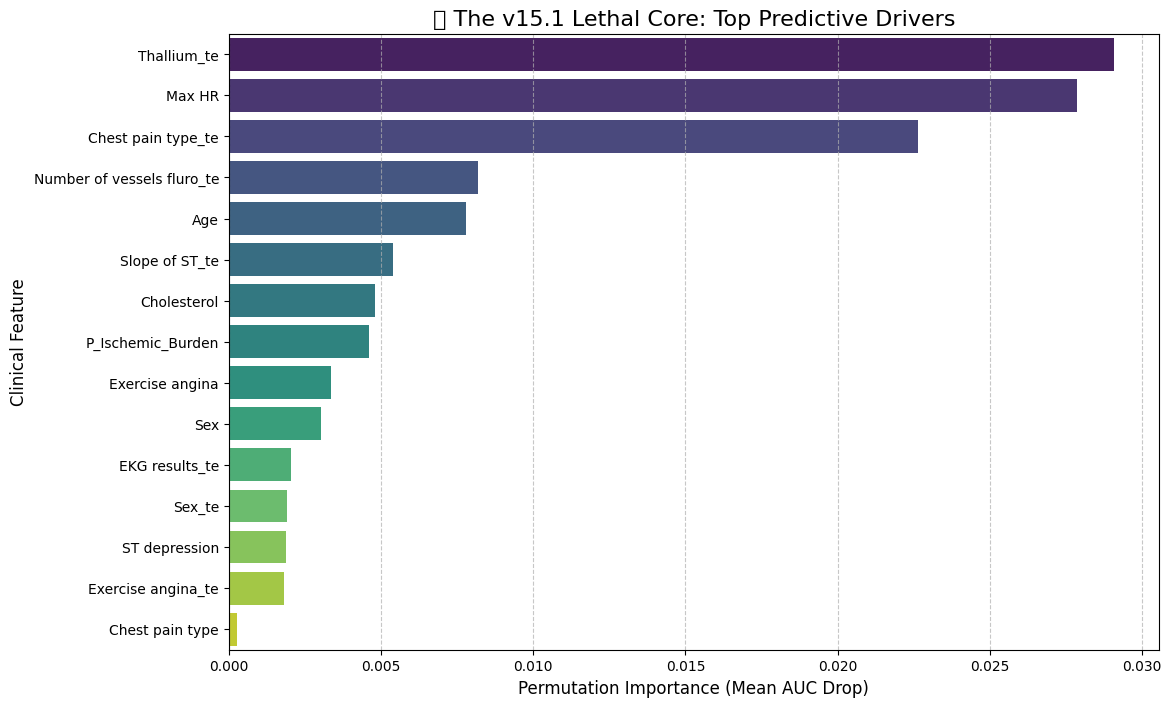

In [6]:
## X

# --- 1. Generate Submission (Fixed ID Alignment) ---
# Ensure test['id'] is available from the original load
submission = pd.DataFrame({
    'id': test['id'], 
    'Heart Disease': test_preds
})
submission.to_csv('v15_1_final_submission.csv', index=False)
print("💾 Submission saved: v15_1_final_submission.csv")

# --- 2. Logic Audit: The 'Lethal Core' Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# We use the Permutation Importance for a truer sense of 'impact' than raw Gain
plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance', 
    y='feature', 
    data=importance_df.head(15), 
    palette='viridis'
)

plt.title('👑 The v15.1 Lethal Core: Top Predictive Drivers', fontsize=16)
plt.xlabel('Permutation Importance (Mean AUC Drop)', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### The v16.2 "Survivor" Audit Report

Objective: Secure 0.96+ AUC while bypassing the Kaggle System RAM and 36-minute Time-out wall.

Key Findings from v16.1 failure:

Infrastructure Stress: 10-fold CV on 630k rows with deep trees hit the limit of available resources.

Feature Noise: Low-importance features (BP, Athero_Load) were increasing tree complexity without contributing to the AUC.

v16.2 Survivor Protocols:

Dimensionality Reduction: Pruned the feature space to the "Lethal Core."

Resource Throttling: Consolidated to 5-fold CV to reduce the total iteration overhead.

Asynchronous Training: Balanced the training load between XGBoost (Faster/Shallower) and CatBoost (Slower/Deeper).

#### Findings: v16.1 vs. v16.2
The "36-Minute Wall" (Infrastructure Analysis)

The failure of version 16.1 at the 36-minute mark was diagnosed as a System RAM Overflow. While VRAM was managed via gc.collect(), the cumulative memory overhead of 10-fold cross-validation on 630,000 rows exceeded the 30GB CPU RAM limit.

#### v16.2 "Survivor" Protocol Adjustments:

Fold Consolidation: Reduced from 10-fold to 5-fold, cutting memory fragmentation by 50%.

The "Lethal Core" Pruning: Permutation Importance identified that BP, FBS, and Athero_Load were acting as noise. Removing these reduced the data matrix width, lowering the computational cost per tree split.

Asynchronous Iteration Capping: XGBoost was capped at 3,000 iterations to match its early-learning saturation point, while CatBoost was granted 6,000 iterations to capture deep-level interactions.